# npE Plotting and Analysis Tools

In [1]:
project_path = '/home/loane2/projects/npe'

## Plot Dephasing

In [4]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import lal

npe_dir = os.path.abspath(os.path.join(project_path, 'npe'))
if npe_dir not in sys.path:
    sys.path.append(npe_dir)

from waveform_analysis import VAE

MSUN_KM = lal.MSUN_SI * lal.G_SI / lal.C_SI ** 2 / 1e3
MSUN_S  = MSUN_KM / lal.C_SI * 1e3

In [3]:
# Import PyTorch network

network_path = './npe/utils/param_estimation_test/npe_network.pt'   # Example network
#network_path = './network/checkpoints/npe-BH/npe-BH_100-epochs.pt'  # BBH network
#network_path = './network/checkpoints/npe-NS/npe-NS_100-epochs.pt'  # BNS network

network_fullpath = os.path.expanduser(os.path.join(project_path, network_path))

device = torch.device('cpu')
kwargs = dict(depth=4, width=512, data_dim=640, grid_dim=2)

model = VAE(**kwargs).to(device)
model.load_state_dict(torch.load(network_fullpath, map_location=device)['model'])
model.eval()
model.train(False)

/tmp/ipykernel_97456/2182020919.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(network_fullpath, map_location=device)['model'])


VAE(
  (raw_encoder): Encoder(
    (fc): Sequential(
      (0): Linear(in_features=640, out_features=512, bias=True)
      (1): Identity()
      (2): ReLU()
      (3): Linear(in_features=512, out_features=512, bias=True)
      (4): Identity()
      (5): ReLU()
      (6): Linear(in_features=512, out_features=512, bias=True)
      (7): Identity()
      (8): ReLU()
      (9): Linear(in_features=512, out_features=512, bias=True)
      (10): Identity()
      (11): ReLU()
      (12): Linear(in_features=512, out_features=512, bias=True)
      (13): Identity()
      (14): ReLU()
      (15): Linear(in_features=512, out_features=3, bias=True)
    )
  )
  (raw_decoder0): Decoder(
    (fc): Sequential(
      (0): Linear(in_features=6, out_features=512, bias=True)
      (1): Identity()
      (2): ReLU()
      (3): Linear(in_features=512, out_features=512, bias=True)
      (4): Identity()
      (5): ReLU()
      (6): Linear(in_features=512, out_features=512, bias=True)
      (7): Identity()
      (8

In [30]:
# Get dephasing values from shape function
f_min = 0.0004
f_max = 0.018
f_num = 640

m_min = 5.0
m_max = 30.0

#z_mag = np.linspace(0, 1, 100)
z_mag = 0.5
z_ang = np.linspace(0, 2*np.pi, 360)

z1 = z_mag * np.cos(z_ang)
z2 = z_mag * np.sin(z_ang)

norm_fac = 1.

print('z1: ', z1.shape)
print('z2: ', z2.shape)

# TODO: Loop the below over all z_theta values
z1 = z1[1]
z2 = z2[1]

print('z1 example: ', z1)
print('z2 example: ', z2)

## TODO: Finish adapting all of this
f_min_geom = f_min*(2*m_min*MSUN_S)
f_max_geom = f_max*(2*m_max*MSUN_S)
# TODO: Should we provide unitless or geometric frequencies?
#freqs = np.linspace(f_min, f_max, f_num)
geom_freqs = np.linspace(f_min_geom, f_max_geom, f_num)
model_loggeom_freqs = np.linspace(np.log10(f_min), np.log10(f_max), f_num)
geom_freqs_cutoff = model_loggeom_freqs[-1]
mask_low = geom_freqs <= 0
mask_high = geom_freqs > geom_freqs_cutoff
mask_mid = ~(mask_low|mask_high)
loggeom_freqs = np.log10(np.append(geom_freqs[mask_mid], geom_freqs_cutoff))
loggeom_freq_range = model_loggeom_freqs[-1] - model_loggeom_freqs[0]
xin = (loggeom_freqs - model_loggeom_freqs[0]) / loggeom_freq_range
xin = torch.tensor(xin, dtype=torch.float32, device=device).view(1, -1)

# TODO: What values of z and cond do we need?
z = torch.tensor([z1/z_mag, z2/z_mag], dtype=torch.float32, device=device).view(1, -1)
#cond = self.gw_params_to_vae_labels(mass_1, mass_2, chi_1, chi_2) # returns: [Mc, eta, chi_sym, chi_asym]
cond = [25, 1, 0, 0]
cond = torch.tensor(cond, dtype=torch.float32, device=device).view(1, -1)
print('z: ', z.shape)
print('cond: ', cond.shape)

Sout, dSout = model.extended_decoder(z, cond, xin)

print('Sout: ', Sout.shape)

# TODO: Finish adapting all of this
xout, dext = Sout.view(-1).cpu().detach().numpy().flatten(), dSout.item()
phases_mod = np.zeros_like(geom_freqs)
phases_mod[mask_mid] = xout[:-1]
phases_mod[mask_high] = xout[-1] + dext / loggeom_freq_range / np.log(10) * (geom_freqs[mask_high] / geom_freqs_cutoff - 1.)
phases_mod *= z_mag * norm_fac

print('phases_mod: ', phases_mod.shape)

z1:  (360,)
z2:  (360,)
z1 example:  0.4999234227506911
z2 example:  0.008750507712914394
z:  torch.Size([1, 2])
cond:  torch.Size([1, 4])
Sout:  torch.Size([1, 1, 1])
phases_mod:  (640,)


/tmp/ipykernel_97456/2318637598.py:39: RuntimeWarning: invalid value encountered in log10
  loggeom_freqs = np.log10(np.append(geom_freqs[mask_mid], geom_freqs_cutoff))


tensor([[[nan]]], grad_fn=<ViewBackward0>)
nan
[nan]
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan na

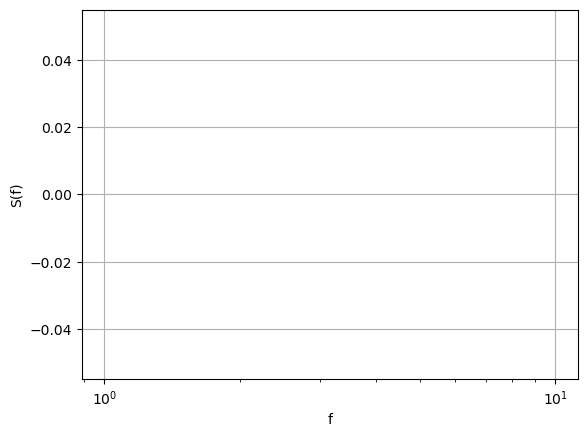

In [38]:
# Plot dephasing
x_vals = geom_freqs
y_vals = phases_mod
print(Sout)
print(dext)
print(xout)
print(phases_mod)

plt.plot(x_vals, y_vals)
plt.xlabel('f')
plt.ylabel('S(f)')
plt.xscale('log')
#plt.yscale('log')
plt.grid()
#plt.legend()

plt.tight_layout
plt.show()